# NIRDuino — Validación de calidad de señal

Notebook para evaluar prototipos NIRDuino. Carga datos de prueba desde TimescaleDB,
trabaja **solo con los pares fuente-detector útiles** definidos por el esquema del probe,
verifica adyacencia geométrica y calcula métricas de calidad de señal.

### Pares incluidos
| Fuente | Detectores largos (RP) | Detector corto (LP) |
|--------|------------------------|---------------------|
| S1 | D8, D10 | D9 (LP1) |
| S2 | D10, D6, D13 | D12 (LP2) |
| S3 | D13, D16, D3 | D15 (LP3) |
| S4 | D7, D8, D6, D10 | D11 (LP4) |
| S5 | D6, D3, D4, D13 | D14 (LP5) |
| S6 | D3, D16 | D1 (LP6) |
| S7 | D7, D4, D6 | D5 (LP7) |
| S8 | D4, D3 | D2 (LP8) |

**Mapeo físico → columna DB:**  
Detectores largos: D3→`d9`, D4→`d10`, D6→`d11`, D7→`d12`, D8→`d13`, D10→`d14`, D13→`d15`, D16→`d16`  
Detectores cortos: D9→`d1`(LP1), D12→`d2`(LP2), D15→`d3`(LP3), D11→`d4`(LP4), D14→`d5`(LP5), D1→`d6`(LP6), D5→`d7`(LP7), D2→`d8`(LP8)

In [57]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import psycopg2
import mne
from pathlib import Path
from scipy import signal as scipy_signal

mne.set_log_level('WARNING')
warnings.filterwarnings('ignore', category=RuntimeWarning)

_cfg = json.loads((Path.home() / '.cogni' / 'config.json').read_text(encoding='utf-8'))
_db  = _cfg['db']
conn = psycopg2.connect(
    host=_db['host'], port=int(_db.get('port', 5432)),
    dbname=_db['dbname'], user=_db['user'], password=_db.get('password', ''),
)
print('Conectado a la base de datos.')

Conectado a la base de datos.


## 1. Selección de sesión de prueba

In [58]:
# ── Listar sesiones disponibles ───────────────────────────────────────────────
conn.rollback()  # resetea transacción abortada si la query anterior falló
sessions_df = pd.read_sql(
    "SELECT session_id, subject_name, started_at, ended_at, frames_count "
    "FROM sessions ORDER BY started_at DESC LIMIT 20",
    conn
)
print(sessions_df.to_string(index=False))

                          session_id    subject_name                       started_at                         ended_at  frames_count
86e8bc2e-eb80-48d8-bca5-a729cd6d1678 Angelo Gonzalez 2026-06-23 21:02:41.090711+00:00 2026-06-23 21:03:37.424802+00:00           246
d9a281b3-a8c3-44f3-900e-33cc8025f7aa Angelo Gonzalez 2026-06-23 21:00:20.604703+00:00 2026-06-23 21:01:11.089754+00:00           222
5a5d7a6a-d2e0-46d1-a097-8e4e064a3fb9 Angelo Gonzalez 2026-06-23 20:58:11.958817+00:00 2026-06-23 20:59:04.567093+00:00           232
64dd3abb-48d8-4ba1-9501-365f6fd7dcbb Angelo Gonzalez 2026-06-23 20:56:02.735428+00:00 2026-06-23 20:57:00.938877+00:00           260
c8ea460e-6b51-4dbc-9fec-f145963af4ca Angelo Gonzalez 2026-06-23 20:53:19.029785+00:00 2026-06-23 20:54:15.195240+00:00           246
1220047f-3980-4e8c-8e41-cc5f9c4d9489           test4 2026-06-18 18:26:28.581831+00:00 2026-06-18 18:28:17.947807+00:00           492
79472473-48f2-4791-89fb-ad150b8b84ec           test3 2026-06-18 18:02

/var/folders/31/xwhnlymx3311fjz1p3vjrp1h0000gn/T/ipykernel_87303/3049217588.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sessions_df = pd.read_sql(


In [59]:
SESSION_ID = "86e8bc2e-eb80-48d8-bca5-a729cd6d1678" # ← cambiar si se necesita otra sesión
print(f'Sesión seleccionada: {SESSION_ID}')

df = pd.read_sql(
    f"SELECT * FROM frames WHERE session_id = '{SESSION_ID}' ORDER BY time_elapsed ASC",
    conn
)
t = df['time_elapsed'].values
sfreq = (len(t) - 1) / (t[-1] - t[0])
print(f'Filas       : {len(df)}')
print(f'Duración    : {t[-1]:.1f} s')
print(f'sfreq       : {sfreq:.2f} Hz')

Sesión seleccionada: 86e8bc2e-eb80-48d8-bca5-a729cd6d1678


/var/folders/31/xwhnlymx3311fjz1p3vjrp1h0000gn/T/ipykernel_87303/304266826.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


Filas       : 246
Duración    : 54.9 s
sfreq       : 4.49 Hz


## 2. Definición de pares útiles y geometría

In [60]:
# ── Posiciones en mm (origen = ⊕, midpoint entre RP7 y E7) ───────────────────
SOURCE_POS = {
    's1': np.array([-65.0,  0.0, 0.0]),
    's2': np.array([-15.0,  0.0, 0.0]),
    's3': np.array([ 40.0,  0.0, 0.0]),
    's4': np.array([-40.0, 25.0, 0.0]),
    's5': np.array([ 15.0, 25.0, 0.0]),
    's6': np.array([ 65.0, 25.0, 0.0]),
    's7': np.array([-15.0, 73.0, 0.0]),
    's8': np.array([ 40.0, 73.0, 0.0]),
}

# Detectores largos (RP): DB key → posición mm
LONG_DET_POS = {
    'd9':  np.array([ 40.0, 25.0, 0.0]),  # D3
    'd10': np.array([ 15.0, 73.0, 0.0]),  # D4
    'd11': np.array([-15.0, 25.0, 0.0]),  # D6
    'd12': np.array([-40.0, 73.0, 0.0]),  # D7
    'd13': np.array([-65.0, 25.0, 0.0]),  # D8
    'd14': np.array([-40.0,  0.0, 0.0]),  # D10
    'd15': np.array([ 15.0,  0.0, 0.0]),  # D13
    'd16': np.array([ 65.0,  0.0, 0.0]),  # D16
}

# Detectores cortos (LP): DB key → posición mm
SHORT_DET_POS = {
    'd1':  np.array([-65.0,  8.0, 0.0]),  # D9/LP1  → S1
    'd2':  np.array([-15.0,  8.0, 0.0]),  # D12/LP2 → S2
    'd3':  np.array([ 40.0,  8.0, 0.0]),  # D15/LP3 → S3
    'd4':  np.array([-40.0, 15.0, 0.0]),  # D11/LP4 → S4
    'd5':  np.array([ 15.0, 15.0, 0.0]),  # D14/LP5 → S5
    'd6':  np.array([ 65.0, 15.0, 0.0]),  # D1/LP6  → S6
    'd7':  np.array([-15.0, 65.0, 0.0]),  # D5/LP7  → S7
    'd8':  np.array([ 40.0, 65.0, 0.0]),  # D2/LP8  → S8
}

# Etiquetas del hardware (D1-D16 tal como aparecen físicamente en el probe)
LONG_PHYSICAL = {
    'd9':'D3', 'd10':'D4', 'd11':'D6', 'd12':'D7',
    'd13':'D8', 'd14':'D10', 'd15':'D13', 'd16':'D16',
}
# Formato: "Dxx (LPn)" — Dxx es el label físico impreso, LPn es el rol
SHORT_PHYSICAL = {
    'd1':'D9 (LP1)', 'd2':'D12 (LP2)', 'd3':'D15 (LP3)', 'd4':'D11 (LP4)',
    'd5':'D14 (LP5)', 'd6':'D1 (LP6)', 'd7':'D5 (LP7)', 'd8':'D2 (LP8)',
}

# ── Pares útiles: (src_db, det_db, tipo) ─────────────────────────────────────
# tipo: 'rp' = canal largo, 'lp' = canal corto
USEFUL_PAIRS = [
    # S1
    ('s1', 'd13', 'rp'),  # S1:D8
    ('s1', 'd14', 'rp'),  # S1:D10
    ('s1', 'd1',  'lp'),  # S1:D9 (LP1)
    # S2
    ('s2', 'd14', 'rp'),  # S2:D10
    ('s2', 'd11', 'rp'),  # S2:D6
    ('s2', 'd15', 'rp'),  # S2:D13
    ('s2', 'd2',  'lp'),  # S2:D12 (LP2)
    # S3
    ('s3', 'd15', 'rp'),  # S3:D13
    ('s3', 'd16', 'rp'),  # S3:D16
    ('s3', 'd9',  'rp'),  # S3:D3
    ('s3', 'd3',  'lp'),  # S3:D15 (LP3)
    # S4
    ('s4', 'd12', 'rp'),  # S4:D7
    ('s4', 'd13', 'rp'),  # S4:D8
    ('s4', 'd11', 'rp'),  # S4:D6
    ('s4', 'd14', 'rp'),  # S4:D10
    ('s4', 'd4',  'lp'),  # S4:D11 (LP4)
    # S5
    ('s5', 'd11', 'rp'),  # S5:D6
    ('s5', 'd9',  'rp'),  # S5:D3
    ('s5', 'd10', 'rp'),  # S5:D4
    ('s5', 'd15', 'rp'),  # S5:D13
    ('s5', 'd5',  'lp'),  # S5:D14 (LP5)
    # S6
    ('s6', 'd9',  'rp'),  # S6:D3
    ('s6', 'd16', 'rp'),  # S6:D16
    ('s6', 'd6',  'lp'),  # S6:D1 (LP6)
    # S7
    ('s7', 'd12', 'rp'),  # S7:D7
    ('s7', 'd10', 'rp'),  # S7:D4
    ('s7', 'd11', 'rp'),  # S7:D6
    ('s7', 'd7',  'lp'),  # S7:D5 (LP7)
    # S8
    ('s8', 'd10', 'rp'),  # S8:D4
    ('s8', 'd9',  'rp'),  # S8:D3
    ('s8', 'd8',  'lp'),  # S8:D2 (LP8)
]

print(f'Pares útiles definidos: {len(USEFUL_PAIRS)}')
print(f'  Canales largos (RP): {sum(1 for *_, t in USEFUL_PAIRS if t == "rp")}')
print(f'  Canales cortos (LP): {sum(1 for *_, t in USEFUL_PAIRS if t == "lp")}')

Pares útiles definidos: 31
  Canales largos (RP): 23
  Canales cortos (LP): 8


## 3. Verificación de adyacencia fuente-detector

In [61]:
ALL_DET_POS = {**LONG_DET_POS, **SHORT_DET_POS}

adjacency_rows = []
for src, det, tipo in USEFUL_PAIRS:
    src_pos = SOURCE_POS[src]
    det_pos = ALL_DET_POS[det]
    dist_mm = np.linalg.norm(src_pos - det_pos)

    if tipo == 'lp':
        phys_det = SHORT_PHYSICAL[det]
        expected = '8–15'
        ok = 5 <= dist_mm <= 20
    else:
        phys_det = LONG_PHYSICAL[det]
        expected = '20–50'
        ok = 20 <= dist_mm <= 55

    adjacency_rows.append({
        'Par': f'{src.upper()}:{phys_det}',
        'src_db': src, 'det_db': det, 'tipo': tipo,
        'dist_mm': round(dist_mm, 1),
        'rango_esperado': expected,
        'OK': '✓' if ok else '✗ REVISAR',
    })

adj_df = pd.DataFrame(adjacency_rows)
fails  = adj_df[adj_df['OK'] != '✓']

print(adj_df[['Par', 'tipo', 'dist_mm', 'rango_esperado', 'OK']].to_string(index=False))
print(f'\nPares fuera de rango: {len(fails)}')
if not fails.empty:
    print(fails[['Par', 'dist_mm', 'rango_esperado']].to_string(index=False))

         Par tipo  dist_mm rango_esperado OK
       S1:D8   rp     25.0          20–50  ✓
      S1:D10   rp     25.0          20–50  ✓
 S1:D9 (LP1)   lp      8.0           8–15  ✓
      S2:D10   rp     25.0          20–50  ✓
       S2:D6   rp     25.0          20–50  ✓
      S2:D13   rp     30.0          20–50  ✓
S2:D12 (LP2)   lp      8.0           8–15  ✓
      S3:D13   rp     25.0          20–50  ✓
      S3:D16   rp     25.0          20–50  ✓
       S3:D3   rp     25.0          20–50  ✓
S3:D15 (LP3)   lp      8.0           8–15  ✓
       S4:D7   rp     48.0          20–50  ✓
       S4:D8   rp     25.0          20–50  ✓
       S4:D6   rp     25.0          20–50  ✓
      S4:D10   rp     25.0          20–50  ✓
S4:D11 (LP4)   lp     10.0           8–15  ✓
       S5:D6   rp     30.0          20–50  ✓
       S5:D3   rp     25.0          20–50  ✓
       S5:D4   rp     48.0          20–50  ✓
      S5:D13   rp     25.0          20–50  ✓
S5:D14 (LP5)   lp     10.0           8–15  ✓
       S6:

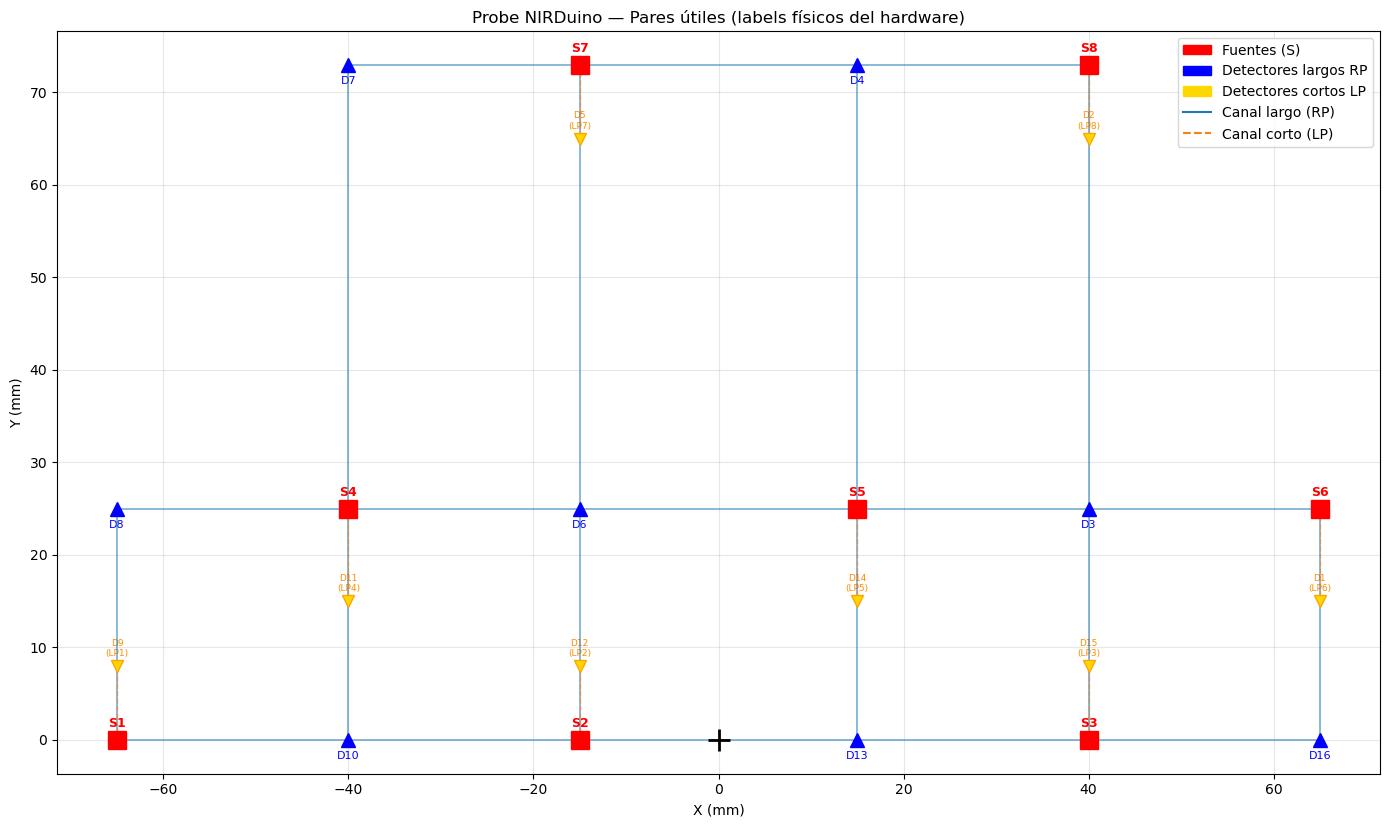

In [62]:
# ── Visualización del probe con pares útiles ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 9))

for src, pos in SOURCE_POS.items():
    ax.plot(pos[0], pos[1], 'rs', markersize=13, zorder=5)
    ax.annotate(src.upper(), pos[:2], textcoords='offset points',
                xytext=(0, 9), ha='center', color='red', fontsize=9, fontweight='bold')

for det, pos in LONG_DET_POS.items():
    ax.plot(pos[0], pos[1], 'b^', markersize=10, zorder=5)
    ax.annotate(LONG_PHYSICAL[det], pos[:2], textcoords='offset points',
                xytext=(0, -14), ha='center', color='blue', fontsize=8)

for det, pos in SHORT_DET_POS.items():
    # SHORT_PHYSICAL formato: "D9 (LP1)" → mostrar "LP1" como etiqueta secundaria
    label_parts = SHORT_PHYSICAL[det].split(' ')   # ["D9", "(LP1)"]
    d_label  = label_parts[0]                      # "D9"
    lp_label = label_parts[1] if len(label_parts) > 1 else ''  # "(LP1)"
    ax.plot(pos[0], pos[1], 'v', markersize=9, color='gold',
            markeredgecolor='orange', zorder=5)
    ax.annotate(f'{d_label}\n{lp_label}', pos[:2],
                textcoords='offset points', xytext=(0, 7),
                ha='center', color='darkorange', fontsize=6.5)

for src, det, tipo in USEFUL_PAIRS:
    sp = SOURCE_POS[src]
    dp = ALL_DET_POS[det]
    color = '#1f77b4' if tipo == 'rp' else '#ff7f0e'
    lw    = 1.2       if tipo == 'rp' else 1.0
    ls    = '-'       if tipo == 'rp' else '--'
    ax.plot([sp[0], dp[0]], [sp[1], dp[1]], color=color,
            linewidth=lw, linestyle=ls, alpha=0.6, zorder=3)

ax.plot(0, 0, 'k+', markersize=16, markeredgewidth=2, zorder=6)
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax.set_xlabel('X (mm)'); ax.set_ylabel('Y (mm)')
ax.set_title('Probe NIRDuino — Pares útiles (labels físicos del hardware)')
ax.legend(handles=[
    mpatches.Patch(color='red',    label='Fuentes (S)'),
    mpatches.Patch(color='blue',   label='Detectores largos RP'),
    mpatches.Patch(color='gold',   label='Detectores cortos LP'),
    plt.Line2D([0],[0], color='#1f77b4', lw=1.5, label='Canal largo (RP)'),
    plt.Line2D([0],[0], color='#ff7f0e', lw=1.5, ls='--', label='Canal corto (LP)'),
])
plt.tight_layout()
plt.show()

## 4. Construcción de MNE Raw (solo pares útiles)

In [63]:
data_arrays, ch_names, src_locs, det_locs, ch_meta = [], [], [], [], []

missing_cols = []
for src, det, tipo in USEFUL_PAIRS:
    det_pos  = ALL_DET_POS[det]
    phys_det = (LONG_PHYSICAL if tipo == 'rp' else SHORT_PHYSICAL)[det]
    for wl in [740, 850]:
        col = f'{src}_{det}_{wl}nm_{tipo}'
        if col not in df.columns:
            missing_cols.append(col)
            continue
        mne_name = f'S{src[1:]}_D{det[1:]} {wl}'
        data_arrays.append(df[col].values.astype(float))
        ch_names.append(mne_name)
        src_locs.append(SOURCE_POS[src] / 1000.0)
        det_locs.append(det_pos / 1000.0)
        ch_meta.append({'src': src, 'det': det, 'tipo': tipo,
                        'wl': wl, 'phys_det': phys_det})

if missing_cols:
    print(f'ATENCIÓN — columnas no encontradas en DB ({len(missing_cols)}):')
    for c in missing_cols:
        print(f'  {c}')

info = mne.create_info(
    ch_names=ch_names,
    sfreq=sfreq,
    ch_types=['fnirs_cw_amplitude'] * len(ch_names),
)
with info._unlock():
    for i, (sp, dp, meta) in enumerate(zip(src_locs, det_locs, ch_meta)):
        info['chs'][i]['loc'][0:3] = (sp + dp) / 2.0
        info['chs'][i]['loc'][3:6] = sp
        info['chs'][i]['loc'][6:9] = dp
        info['chs'][i]['loc'][9]   = float(meta['wl'])

raw = mne.io.RawArray(np.array(data_arrays), info, verbose=False)

dists_m = mne.preprocessing.nirs.source_detector_distances(raw.info)
n_long  = sum(1 for m in ch_meta if m['tipo'] == 'rp')
n_short = sum(1 for m in ch_meta if m['tipo'] == 'lp')
print(f'Raw creado: {raw.info["nchan"]} canales ({n_long} RP + {n_short} LP)')
print(f'Distancias RP : {dists_m[::2][:n_long//2].min()*1e3:.0f}–'
      f'{dists_m[::2][:n_long//2].max()*1e3:.0f} mm')
print(f'Distancias LP : {dists_m[n_long::2].min()*1e3:.0f}–'
      f'{dists_m[n_long::2].max()*1e3:.0f} mm')

# ── Mapeo MNE ch_name → label físico del hardware ────────────────────────────
# Permite identificar el conector físico (D1-D16, S1-S8) a partir del nombre MNE.
# Formato: "S1_D13 740" (MNE) → "S1:D8 740nm" (hardware)
mne_to_hw = {
    ch: f'{m["src"].upper()}:{m["phys_det"].split(" ")[0]} {m["wl"]}nm'
    for ch, m in zip(ch_names, ch_meta)
}
print('\nEjemplos de mapeo MNE → hardware:')
for mne_ch, hw_label in list(mne_to_hw.items())[:4]:
    print(f'  {mne_ch:20s} → {hw_label}')

Raw creado: 62 canales (46 RP + 16 LP)
Distancias RP : 8–48 mm
Distancias LP : 8–48 mm

Ejemplos de mapeo MNE → hardware:
  S1_D13 740           → S1:D8 740nm
  S1_D13 850           → S1:D8 850nm
  S1_D14 740           → S1:D10 740nm
  S1_D14 850           → S1:D10 850nm


## 5. Scalp Coupling Index (SCI)

SCI mide la correlación cardíaca entre los dos canales de longitud de onda de cada par.
Valores > 0.7 indican buen acoplamiento óptico. Los canales LP tienen SCI bajo por diseño
(señal superficial, pulso cardíaco débil) — no se marcan como malos.

Umbral SCI  : 0.7
Canales RP malos (SCI < 0.7): 46
  HW: S1:D8 740nm           |  MNE: S1_D13 740            |  SCI = 0.054
  HW: S1:D8 850nm           |  MNE: S1_D13 850            |  SCI = 0.054
  HW: S1:D10 740nm          |  MNE: S1_D14 740            |  SCI = -0.031
  HW: S1:D10 850nm          |  MNE: S1_D14 850            |  SCI = -0.031
  HW: S2:D10 740nm          |  MNE: S2_D14 740            |  SCI = 0.040
  HW: S2:D10 850nm          |  MNE: S2_D14 850            |  SCI = 0.040
  HW: S2:D6 740nm           |  MNE: S2_D11 740            |  SCI = 0.032
  HW: S2:D6 850nm           |  MNE: S2_D11 850            |  SCI = 0.032
  HW: S2:D13 740nm          |  MNE: S2_D15 740            |  SCI = 0.075
  HW: S2:D13 850nm          |  MNE: S2_D15 850            |  SCI = 0.075
  HW: S3:D13 740nm          |  MNE: S3_D15 740            |  SCI = 0.079
  HW: S3:D13 850nm          |  MNE: S3_D15 850            |  SCI = 0.079
  HW: S3:D16 740nm          |  MNE: S3_D16 740            |  SCI = -0.0

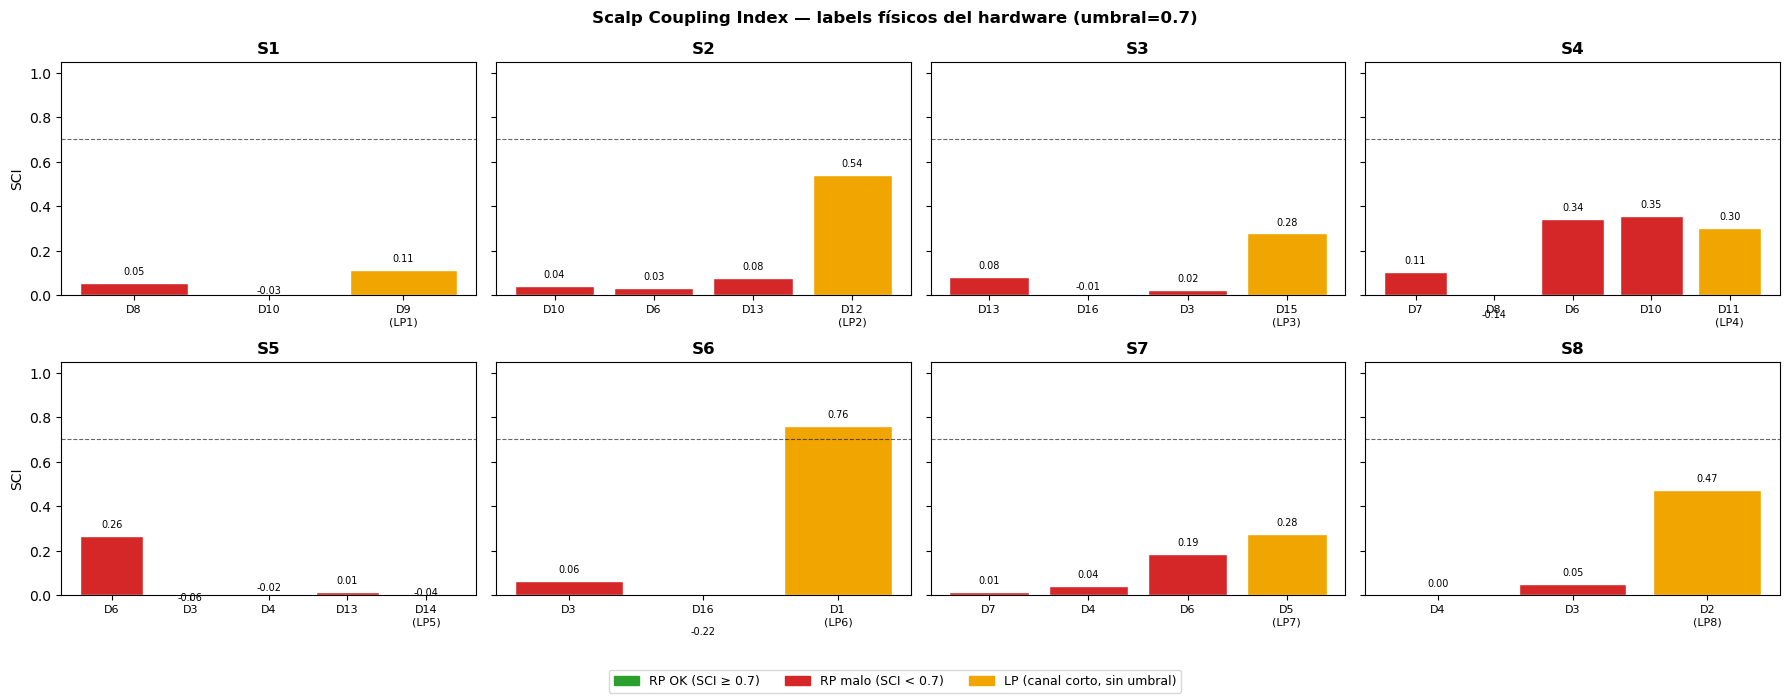

In [64]:
raw_od = mne.preprocessing.nirs.optical_density(raw)
sci    = mne.preprocessing.nirs.scalp_coupling_index(raw_od)

SCI_THRESHOLD = 0.7
SHORT_CH_M    = 0.020  # 20 mm — umbral para clasificar como corto

is_short_ch = dists_m < SHORT_CH_M

bad_chs = [
    ch for ch, s, short in zip(raw_od.ch_names, sci, is_short_ch)
    if s < SCI_THRESHOLD and not short
]
raw_od.info['bads'] = bad_chs

print(f'Umbral SCI  : {SCI_THRESHOLD}')
print(f'Canales RP malos (SCI < {SCI_THRESHOLD}): {len(bad_chs)}')
for ch in bad_chs:
    i   = raw_od.ch_names.index(ch)
    hw  = mne_to_hw.get(ch, ch)   # label físico: "S1:D8 740nm"
    print(f'  HW: {hw:20s}  |  MNE: {ch:20s}  |  SCI = {sci[i]:.3f}')

# ── Gráfica SCI por par (agrupado por fuente) ─────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 7), sharey=True)
axes = axes.flatten()

sources_order = ['s1','s2','s3','s4','s5','s6','s7','s8']

for ax_i, src in enumerate(sources_order):
    ax = axes[ax_i]
    src_indices = [i for i, m in enumerate(ch_meta) if m['src'] == src and m['wl'] == 740]

    labels, heights, colors = [], [], []
    for idx in src_indices:
        meta = ch_meta[idx]
        val  = sci[idx]
        # Mostrar label físico del hardware (D8, D10, D9 (LP1), ...)
        hw_det = meta['phys_det'].split(' ')[0]  # "D8" de "D8", "D9" de "D9 (LP1)"
        if meta['tipo'] == 'lp':
            # Incluir rol LP para distinguirlos visualmente
            lp_role = meta['phys_det'].split(' ')[1] if ' ' in meta['phys_det'] else ''
            hw_det  = f"{hw_det}\n{lp_role}"
        labels.append(hw_det)
        heights.append(val)
        if meta['tipo'] == 'lp':
            colors.append('#f0a500')  # naranja = LP (sin umbral)
        elif val >= SCI_THRESHOLD:
            colors.append('#2ca02c')  # verde = OK
        else:
            colors.append('#d62728')  # rojo = malo

    bars = ax.bar(range(len(labels)), heights, color=colors, edgecolor='white')
    ax.axhline(SCI_THRESHOLD, color='k', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(src.upper(), fontweight='bold')
    ax.set_ylabel('SCI' if ax_i % 4 == 0 else '')
    for bar, val in zip(bars, heights):
        ax.text(bar.get_x() + bar.get_width()/2, min(val + 0.03, 0.98),
                f'{val:.2f}', ha='center', va='bottom', fontsize=7)

fig.suptitle(f'Scalp Coupling Index — labels físicos del hardware (umbral={SCI_THRESHOLD})',
             fontweight='bold')
legend_patches = [
    mpatches.Patch(color='#2ca02c', label=f'RP OK (SCI ≥ {SCI_THRESHOLD})'),
    mpatches.Patch(color='#d62728', label=f'RP malo (SCI < {SCI_THRESHOLD})'),
    mpatches.Patch(color='#f0a500', label='LP (canal corto, sin umbral)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=9)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## 6. Señal cruda y espectro de potencia

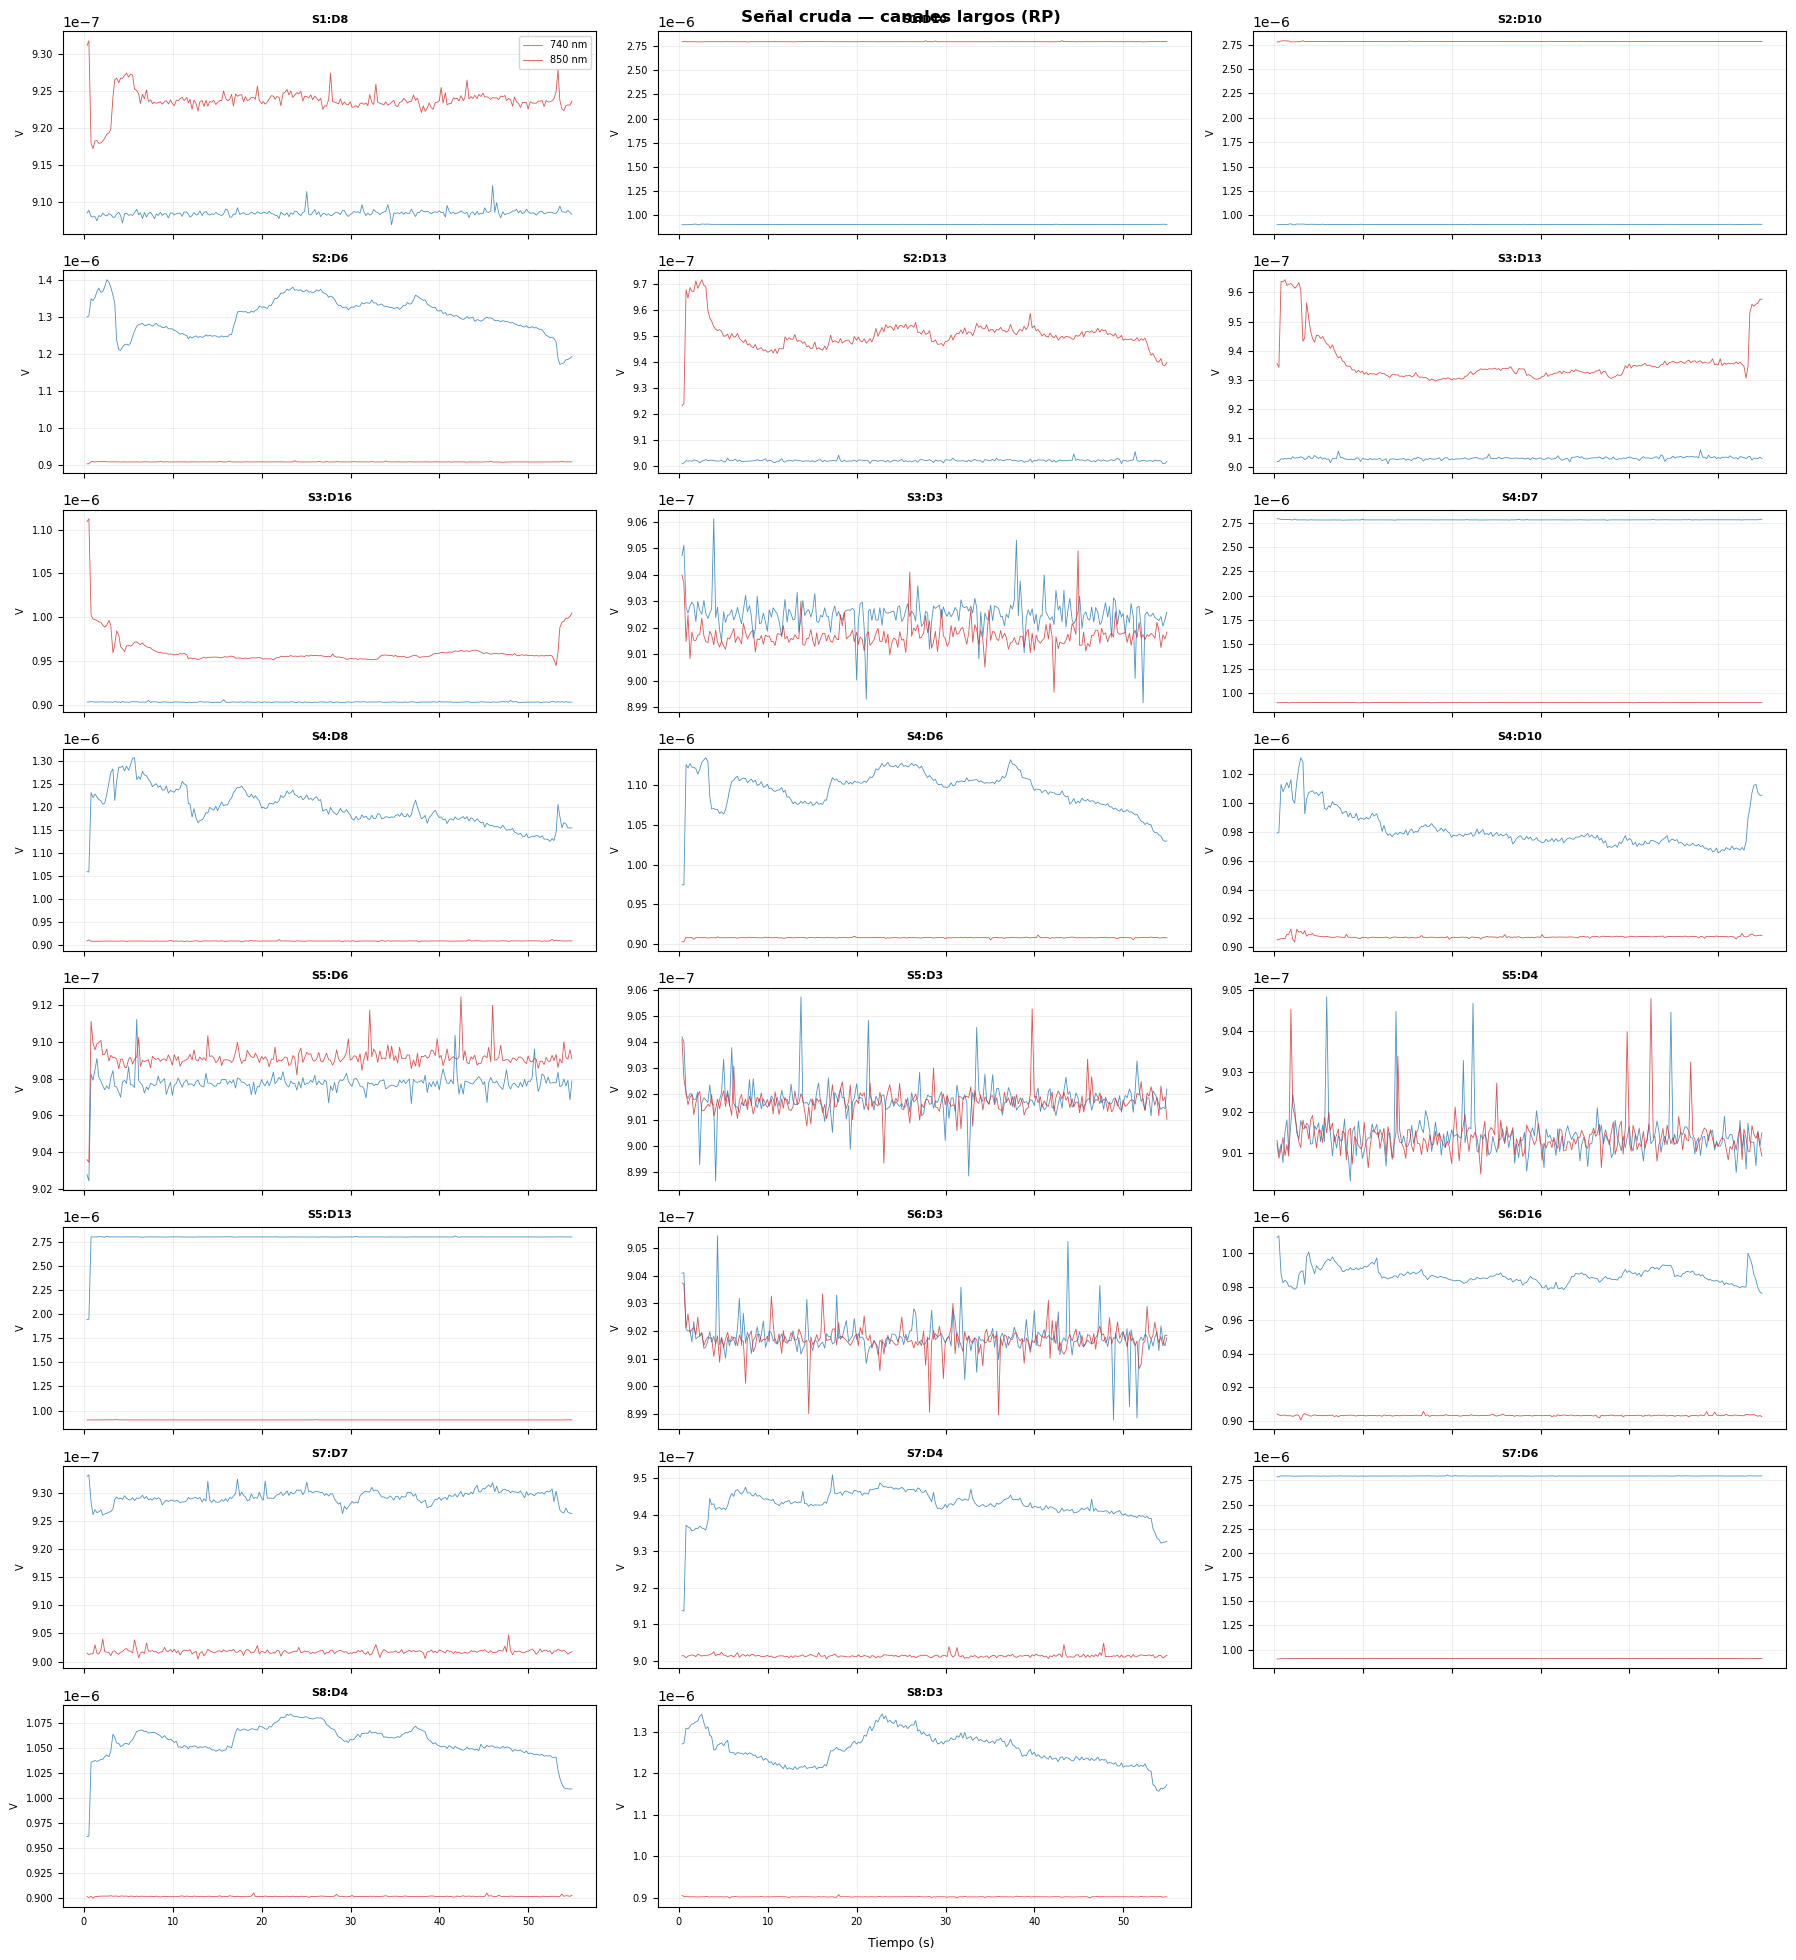

In [65]:
# ── Señal cruda en amplitud (voltaje) — un par por fila ───────────────────────
pairs_to_plot = [(src, det, tipo) for src, det, tipo in USEFUL_PAIRS if tipo == 'rp']
n_plot  = len(pairs_to_plot)
n_cols  = 3
n_rows  = (n_plot + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 2.5), sharex=True)
axes = axes.flatten()

for ax_i, (src, det, tipo) in enumerate(pairs_to_plot):
    ax = axes[ax_i]
    phys = LONG_PHYSICAL[det]
    for wl, color in [(740, '#1f77b4'), (850, '#d62728')]:
        col = f'{src}_{det}_{wl}nm_{tipo}'
        if col in df.columns:
            ax.plot(t, df[col].values * 5.0 / 8_388_608,
                    color=color, linewidth=0.6, alpha=0.8, label=f'{wl} nm')
    ax.set_title(f'{src.upper()}:{phys}', fontsize=8, fontweight='bold')
    ax.set_ylabel('V', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)
    if ax_i == 0:
        ax.legend(fontsize=7)

for ax in axes[n_plot:]:
    ax.set_visible(False)

fig.supxlabel('Tiempo (s)', fontsize=9)
fig.suptitle('Señal cruda — canales largos (RP)', fontweight='bold')
plt.tight_layout()
plt.show()

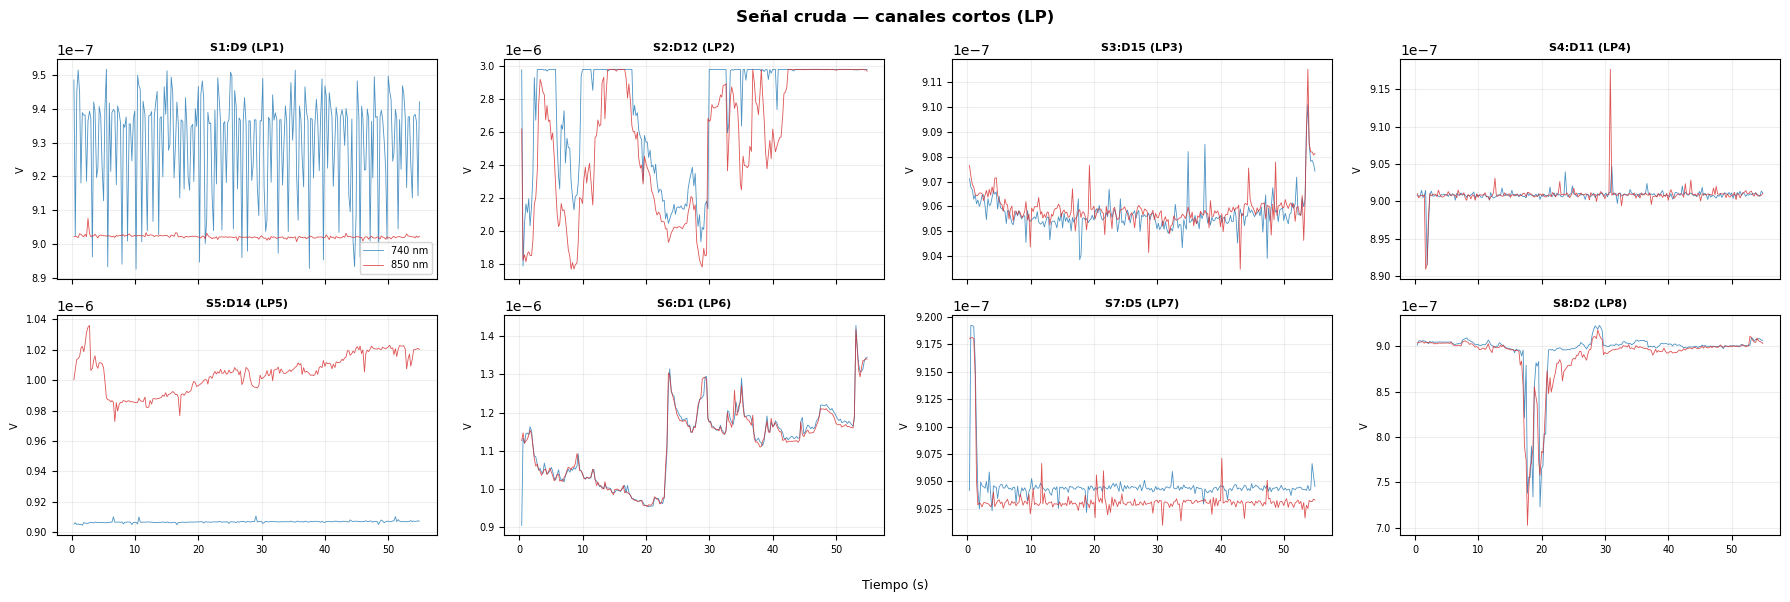

In [66]:
# ── Señal cruda — canales cortos (LP) ────────────────────────────────────────
lp_pairs = [(src, det, tipo) for src, det, tipo in USEFUL_PAIRS if tipo == 'lp']

fig, axes = plt.subplots(2, 4, figsize=(18, 6), sharex=True)
axes = axes.flatten()

for ax_i, (src, det, tipo) in enumerate(lp_pairs):
    ax = axes[ax_i]
    phys = SHORT_PHYSICAL[det]
    for wl, color in [(740, '#1f77b4'), (850, '#d62728')]:
        col = f'{src}_{det}_{wl}nm_{tipo}'
        if col in df.columns:
            ax.plot(t, df[col].values * 5.0 / 8_388_608,
                    color=color, linewidth=0.6, alpha=0.8, label=f'{wl} nm')
    ax.set_title(f'{src.upper()}:{phys}', fontsize=8, fontweight='bold')
    ax.set_ylabel('V', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.2)
    if ax_i == 0:
        ax.legend(fontsize=7)

for ax in axes[len(lp_pairs):]:
    ax.set_visible(False)

fig.supxlabel('Tiempo (s)', fontsize=9)
fig.suptitle('Señal cruda — canales cortos (LP)', fontweight='bold')
plt.tight_layout()
plt.show()

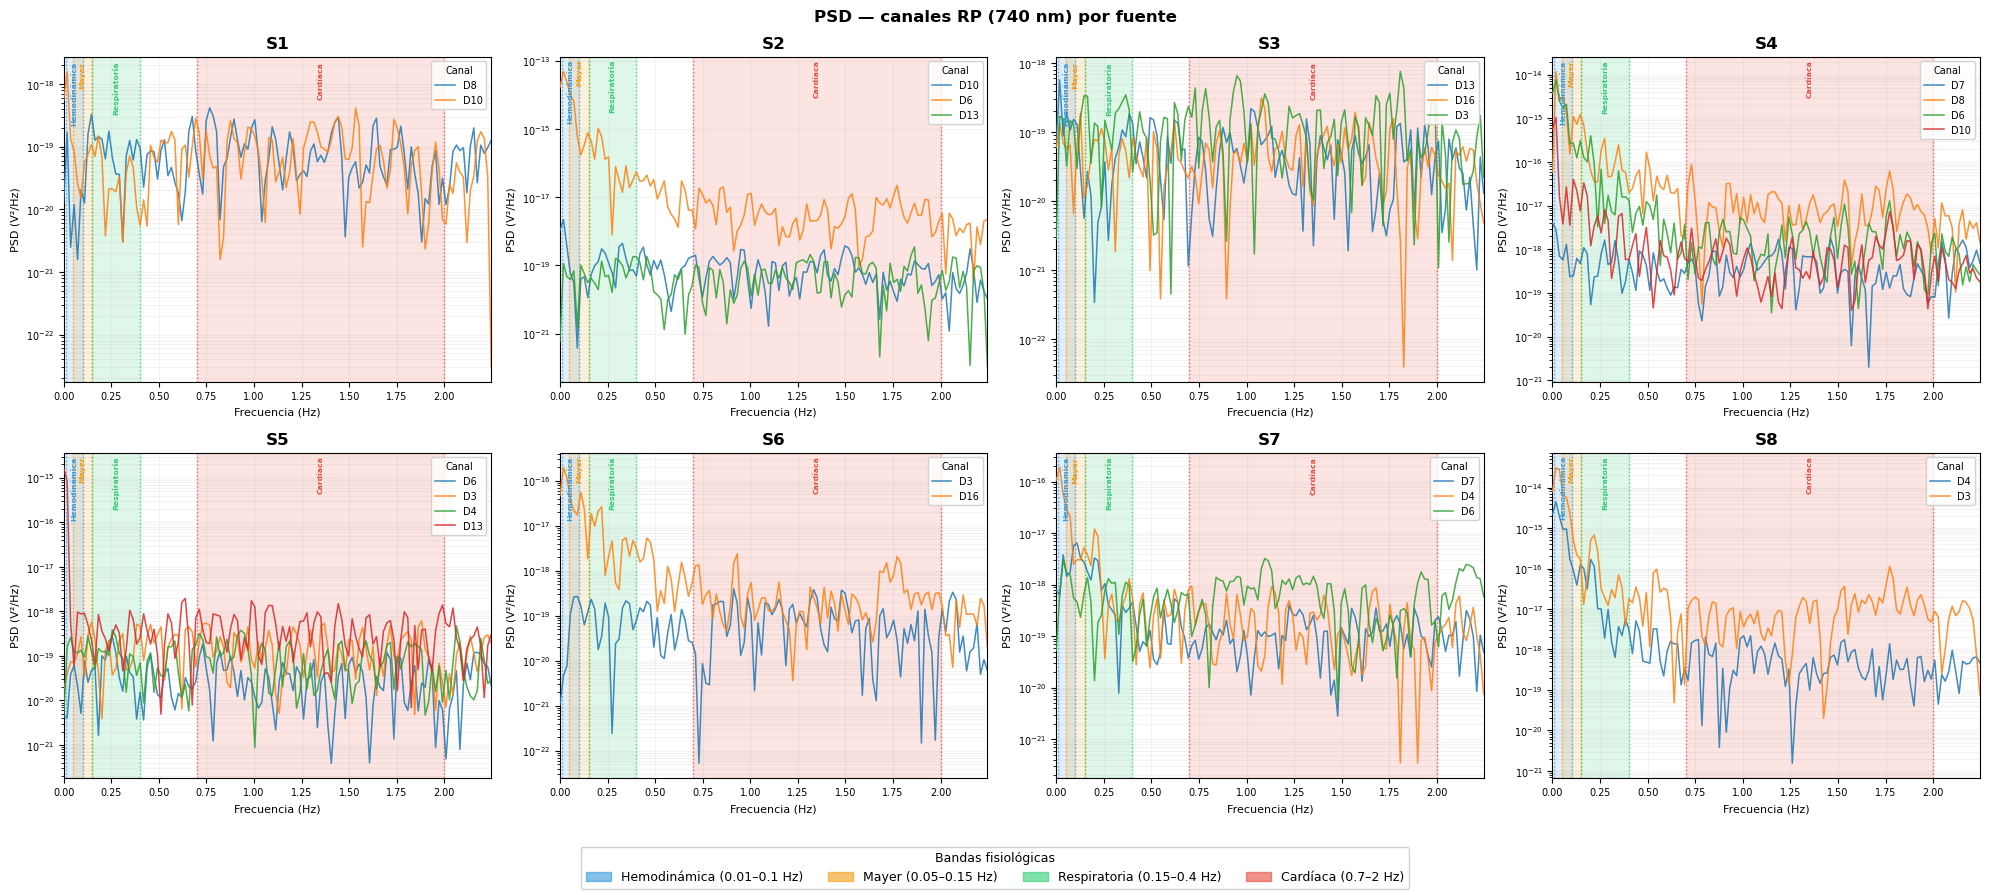

In [67]:
# ── Densidad espectral de potencia (PSD) ─────────────────────────────────────
# Cada banda tiene color propio; se dibuja como franja + líneas de borde + etiqueta
BANDS = [
    ('Hemodinámica\n(0.01–0.1 Hz)',  0.01, 0.10, '#3498db'),  # azul
    ('Mayer\n(0.05–0.15 Hz)',        0.05, 0.15, '#f39c12'),  # naranja
    ('Respiratoria\n(0.15–0.4 Hz)', 0.15, 0.40, '#2ecc71'),  # verde
    ('Cardíaca\n(0.7–2 Hz)',         0.70, 2.00, '#e74c3c'),  # rojo
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax_i, src in enumerate(sources_order):
    ax = axes[ax_i]
    src_rp_pairs = [(s, d, tp) for s, d, tp in USEFUL_PAIRS if s == src and tp == 'rp']

    # Dibujar señales primero (quedan sobre las bandas)
    for src_, det, tipo in src_rp_pairs:
        col = f'{src_}_{det}_740nm_{tipo}'
        if col not in df.columns:
            continue
        sig = df[col].values * 5.0 / 8_388_608
        f_psd, pxx = scipy_signal.welch(sig, fs=sfreq, nperseg=min(256, len(sig)))
        ax.semilogy(f_psd, pxx, linewidth=1.1, alpha=0.85,
                    label=LONG_PHYSICAL[det], zorder=3)

    # Bandas: franja de fondo + bordes punteados
    for band_label, flo, fhi, bcolor in BANDS:
        ax.axvspan(flo, fhi, alpha=0.15, color=bcolor, zorder=1)
        ax.axvline(flo, color=bcolor, linewidth=1.0, linestyle=':', alpha=0.8, zorder=2)
        ax.axvline(fhi, color=bcolor, linewidth=1.0, linestyle=':', alpha=0.8, zorder=2)

    # Etiquetas de banda en la parte superior del eje
    ymin, ymax = ax.get_ylim()
    for band_label, flo, fhi, bcolor in BANDS:
        fc = (flo + fhi) / 2
        ax.text(fc, ymax * 0.85, band_label.split('\n')[0],
                ha='center', va='top', fontsize=5.5, color=bcolor,
                fontweight='bold', rotation=90, zorder=4)

    ax.set_xlim(0, min(2.5, sfreq / 2))
    ax.set_xlabel('Frecuencia (Hz)', fontsize=8)
    ax.set_ylabel('PSD (V²/Hz)', fontsize=8)
    ax.set_title(src.upper(), fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.15, which='both')
    ax.legend(fontsize=7, loc='upper right', framealpha=0.85,
              title='Canal', title_fontsize=7)

# ── Leyenda de bandas compartida abajo ───────────────────────────────────────
band_patches = [
    mpatches.Patch(color=bcolor, alpha=0.6, label=lbl.replace('\n', ' '))
    for lbl, flo, fhi, bcolor in BANDS
]
fig.legend(handles=band_patches, loc='lower center', ncol=4,
           fontsize=9, title='Bandas fisiológicas', title_fontsize=9,
           framealpha=0.9)

fig.suptitle('PSD — canales RP (740 nm) por fuente', fontweight='bold', fontsize=12)
plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

## 7. SNR cardíaco por canal

Relación señal/ruido estimada en la banda cardíaca (0.7–2 Hz) vs. banda pre-cardíaca
(0.3–0.7 Hz). Esta referencia existe siempre dentro del Nyquist del NIRDuino (~2.28 Hz)
y es estándar para sistemas fNIRS de baja tasa de muestreo (~5 Hz).

> **Interpretación:** SNR > 0 dB → la banda cardíaca tiene más potencia que la baseline
> pre-cardíaca, lo que indica presencia de pulso. SNR < 0 dB → el pulso no es
> distinguible del ruido de baja frecuencia.

In [68]:
def band_power(sig, fs, flo, fhi):
    f, pxx = scipy_signal.welch(sig, fs=fs, nperseg=min(256, len(sig)))
    mask = (f >= flo) & (f <= fhi)
    integrate = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz
    return integrate(pxx[mask], f[mask]) if mask.any() else 0.0

CARDIAC_LO = 0.70
CARDIAC_HI = 2.00
# Banda de ruido: pre-cardíaca (0.3–0.7 Hz).
# Siempre existe dentro del Nyquist del NIRDuino (~2.28 Hz) independientemente de sfreq,
# y es la referencia estándar para sistemas fNIRS de baja frecuencia de muestreo.
NOISE_LO = 0.30
NOISE_HI = 0.70

nyquist = sfreq / 2.0
print(f'sfreq          : {sfreq:.2f} Hz  →  Nyquist = {nyquist:.2f} Hz')
print(f'Banda cardíaca : {CARDIAC_LO}–{CARDIAC_HI} Hz')
print(f'Banda de ruido : {NOISE_LO}–{NOISE_HI} Hz  (pre-cardíaca)')
if CARDIAC_HI > nyquist:
    print(f'AVISO: banda cardíaca ({CARDIAC_HI} Hz) supera Nyquist ({nyquist:.2f} Hz)')

snr_rows = []
for src, det, tipo in USEFUL_PAIRS:
    phys = (LONG_PHYSICAL if tipo == 'rp' else SHORT_PHYSICAL)[det]
    for wl in [740, 850]:
        col = f'{src}_{det}_{wl}nm_{tipo}'
        if col not in df.columns:
            continue
        sig = df[col].values * 5.0 / 8_388_608
        p_cardiac = band_power(sig, sfreq, CARDIAC_LO, min(CARDIAC_HI, nyquist))
        p_noise   = band_power(sig, sfreq, NOISE_LO, NOISE_HI)
        snr_db    = 10 * np.log10(p_cardiac / p_noise) if p_noise > 0 else np.nan
        snr_rows.append({
            'Par': f'{src.upper()}:{phys}',
            'src': src, 'det': det, 'tipo': tipo, 'wl': wl,
            'SNR_cardiac_dB': round(snr_db, 2) if not np.isnan(snr_db) else np.nan,
            'SCI_740': round(sci[ch_names.index(f'S{src[1:]}_D{det[1:]} 740')], 3)
                       if f'S{src[1:]}_D{det[1:]} 740' in ch_names else None,
        })

snr_df = pd.DataFrame(snr_rows)

summary = (
    snr_df.groupby(['Par', 'tipo'])
    .agg(SNR_avg_dB=('SNR_cardiac_dB', 'mean'),
         SCI=('SCI_740', 'first'))
    .reset_index()
    .sort_values('SNR_avg_dB', ascending=False)
)
print()
print(summary.to_string(index=False))

sfreq          : 4.49 Hz  →  Nyquist = 2.25 Hz
Banda cardíaca : 0.7–2.0 Hz
Banda de ruido : 0.3–0.7 Hz  (pre-cardíaca)

         Par tipo  SNR_avg_dB    SCI
      S1:D10   rp       8.190 -0.031
       S5:D4   rp       6.860 -0.015
 S1:D9 (LP1)   lp       6.500  0.114
       S4:D7   rp       6.205  0.105
       S7:D6   rp       6.070  0.185
      S2:D10   rp       5.855  0.040
       S5:D6   rp       5.840  0.264
 S7:D5 (LP7)   lp       5.660  0.275
       S3:D3   rp       5.645  0.024
S4:D11 (LP4)   lp       5.260  0.300
       S7:D7   rp       5.150  0.012
       S1:D8   rp       4.970  0.054
       S7:D4   rp       4.745  0.041
      S5:D13   rp       4.545  0.013
S3:D15 (LP3)   lp       4.500  0.277
      S2:D13   rp       4.500  0.075
       S6:D3   rp       4.360  0.062
       S8:D3   rp       4.340  0.048
       S5:D3   rp       4.280 -0.064
      S4:D10   rp       3.945  0.354
       S4:D8   rp       2.265 -0.141
       S8:D4   rp       2.120  0.002
      S3:D16   rp       2.065

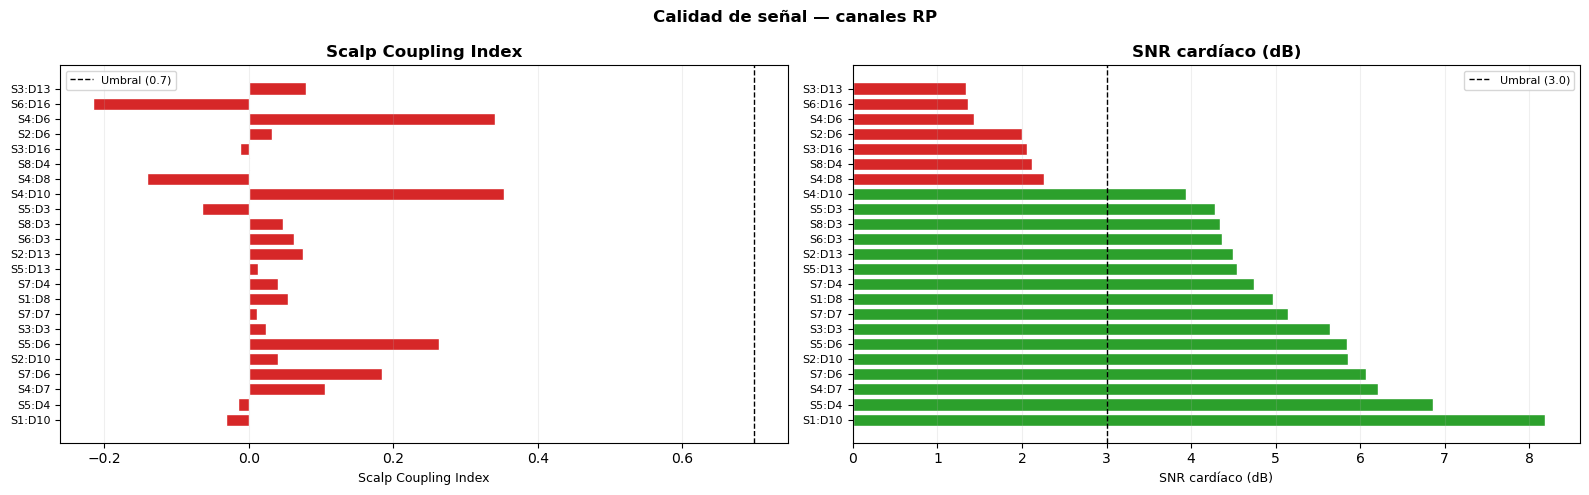

In [69]:
# ── Heatmap SCI × SNR cardíaco ────────────────────────────────────────────────
rp_summary = summary[summary['tipo'] == 'rp'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, label, thresh in [
    (axes[0], 'SCI', 'Scalp Coupling Index', SCI_THRESHOLD),
    (axes[1], 'SNR_avg_dB', 'SNR cardíaco (dB)', 3.0),
]:
    vals   = rp_summary[metric].values
    labels = rp_summary['Par'].values
    colors = ['#2ca02c' if v >= thresh else '#d62728' for v in vals]
    bars   = ax.barh(range(len(labels)), vals, color=colors, edgecolor='white')
    ax.axvline(thresh, color='k', linestyle='--', linewidth=1,
               label=f'Umbral ({thresh})')
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel(label, fontsize=9)
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='x')

plt.suptitle('Calidad de señal — canales RP', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Resumen ejecutivo

In [70]:
# ── Tabla resumen final ───────────────────────────────────────────────────────
final = rp_summary.copy()
final['SCI_OK']  = final['SCI'] >= SCI_THRESHOLD
final['SNR_OK']  = final['SNR_avg_dB'] >= 3.0
final['CALIDAD'] = final.apply(
    lambda r: 'BUENA' if r['SCI_OK'] and r['SNR_OK']
              else ('SCI bajo' if not r['SCI_OK'] and r['SNR_OK']
              else ('SNR bajo' if r['SCI_OK'] and not r['SNR_OK']
              else 'MALA')),
    axis=1
)

print('=== RESUMEN DE CALIDAD DE SEÑAL ===')
print(f'Sesión    : {SESSION_ID}')
print(f'Duración  : {t[-1]:.1f} s @ {sfreq:.2f} Hz')
print(f'Pares RP  : {len(rp_summary)}')
print(f'  BUENA   : {(final["CALIDAD"]=="BUENA").sum()}')
print(f'  SCI bajo: {(final["CALIDAD"]=="SCI bajo").sum()}')
print(f'  SNR bajo: {(final["CALIDAD"]=="SNR bajo").sum()}')
print(f'  MALA    : {(final["CALIDAD"]=="MALA").sum()}')
print()
print(final[['Par', 'SCI', 'SNR_avg_dB', 'CALIDAD']]
      .sort_values('CALIDAD')
      .to_string(index=False))

# Pares a revisar
to_review = final[final['CALIDAD'] != 'BUENA']
if not to_review.empty:
    print(f'\nPares que requieren revisión ({len(to_review)}):')
    for _, row in to_review.iterrows():
        print(f'  {row["Par"]:20s}  SCI={row["SCI"]:.3f}  SNR={row["SNR_avg_dB"]:.1f} dB  → {row["CALIDAD"]}')
else:
    print('\nTodos los pares RP pasan los criterios de calidad.')

=== RESUMEN DE CALIDAD DE SEÑAL ===
Sesión    : 86e8bc2e-eb80-48d8-bca5-a729cd6d1678
Duración  : 54.9 s @ 4.49 Hz
Pares RP  : 23
  BUENA   : 0
  SCI bajo: 16
  SNR bajo: 0
  MALA    : 7

   Par    SCI  SNR_avg_dB  CALIDAD
S3:D13  0.079       1.340     MALA
 S4:D6  0.341       1.430     MALA
 S2:D6  0.032       1.995     MALA
S3:D16 -0.012       2.065     MALA
 S8:D4  0.002       2.120     MALA
 S4:D8 -0.141       2.265     MALA
S6:D16 -0.215       1.360     MALA
S4:D10  0.354       3.945 SCI bajo
 S5:D3 -0.064       4.280 SCI bajo
 S8:D3  0.048       4.340 SCI bajo
 S6:D3  0.062       4.360 SCI bajo
S1:D10 -0.031       8.190 SCI bajo
 S7:D4  0.041       4.745 SCI bajo
 S1:D8  0.054       4.970 SCI bajo
 S7:D7  0.012       5.150 SCI bajo
 S3:D3  0.024       5.645 SCI bajo
 S5:D6  0.264       5.840 SCI bajo
S2:D10  0.040       5.855 SCI bajo
 S7:D6  0.185       6.070 SCI bajo
 S4:D7  0.105       6.205 SCI bajo
 S5:D4 -0.015       6.860 SCI bajo
S5:D13  0.013       4.545 SCI bajo
S2:D13  